In [8]:
# import torch
#################################### For Image ####################################
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from pathlib import Path
# Load the model
model = build_sam3_image_model()
processor = Sam3Processor(model)

image_path = "/home/gatv-projects/Desktop/project/playground/lol_gameplay_top_left_hud.png"


# Load an image
image = Image.open(image_path).convert("RGB")
inference_state = processor.set_image(image)
# Prompt the model with text
output = processor.set_text_prompt(state=inference_state, prompt="Character.")

# Get the masks, bounding boxes, and scores
masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

print(f"Detected {len(masks)} masks.")
for i, (mask, box, score) in enumerate(zip(masks, boxes, scores)):
    print(f"Mask {i+1}: Box={box.tolist()}, Score={score.item():.4f}")  

#################################### For Video ####################################

# from sam3.model_builder import build_sam3_video_predictor

# video_predictor = build_sam3_video_predictor()
# video_path = "<YOUR_VIDEO_PATH>" # a JPEG folder or an MP4 video file
# # Start a session
# response = video_predictor.handle_request(
#     request=dict(
#         type="start_session",
#         resource_path=video_path,
#     )
# )
# response = video_predictor.handle_request(
#     request=dict(
#         type="add_prompt",
#         session_id=response["session_id"],
#         frame_index=0, # Arbitrary frame index
#         text="<YOUR_TEXT_PROMPT>",
#     )
# )
# output = response["outputs"]


Detected 6 masks.
Mask 1: Box=[165.8836212158203, 60.667991638183594, 184.00399780273438, 81.54751586914062], Score=0.6728
Mask 2: Box=[122.48548126220703, 60.77647018432617, 141.2274627685547, 81.12283325195312], Score=0.6783
Mask 3: Box=[228.778564453125, 60.34476852416992, 248.27809143066406, 80.49764251708984], Score=0.7179
Mask 4: Box=[100.16384887695312, 13.383880615234375, 142.7112274169922, 56.49680709838867], Score=0.7902
Mask 5: Box=[237.30007934570312, 95.58099365234375, 252.3067626953125, 113.51583099365234], Score=0.6001
Mask 6: Box=[209.7005615234375, 61.83580780029297, 225.04319763183594, 80.53325653076172], Score=0.6794


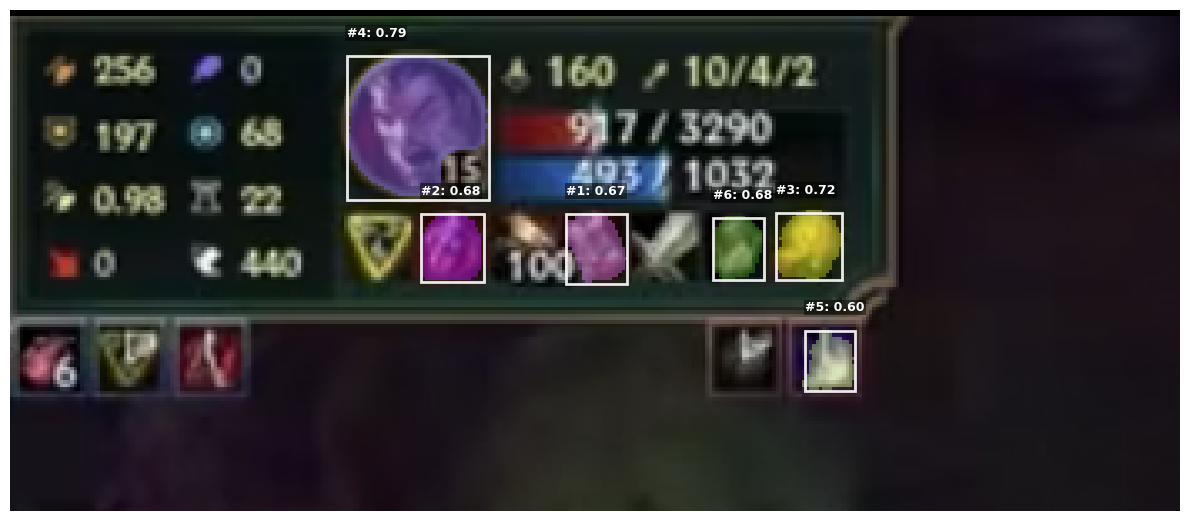

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def show_masks_robust(image, masks, boxes=None, scores=None):
    # --- 1. PRE-PROCESSING ---
    image = image.convert("RGB")
    img_np = np.array(image)
    
    # Handle GPU tensors
    if hasattr(masks, 'cpu'):
        masks = masks.cpu().numpy()
    if boxes is not None and hasattr(boxes, 'cpu'):
        boxes = boxes.cpu().numpy()

    # --- 2. SHAPE CORRECTION ---
    # We need shape (N, H, W)
    if masks.ndim == 4:
        # Standard SAM output is often (1, N, H, W) -> Squeeze dim 0
        if masks.shape[0] == 1:
            masks = masks.squeeze(0)
        # Sometimes it is (N, 1, H, W) -> Squeeze dim 1
        elif masks.shape[1] == 1:
            masks = masks.squeeze(1)
            
    # --- 3. LOGIT VS PROBABILITY CORRECTION (The likely bug) ---
    # If values are floats (positive and negative), they are LOGITS.
    # We must threshold them at 0.0.
    if masks.dtype.kind in ('f', 'c'): 
        masks_bool = masks > 0.0
    else:
        masks_bool = masks.astype(bool)

    # --- 4. VISUALIZATION ---
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)

    # Generate distinct colors
    rng = np.random.default_rng(42)
    colors = rng.random((len(masks_bool), 3)) # Float colors [0, 1] for matplotlib

    # Draw Masks using 'imshow' with alpha for cleaner blending
    # This prevents the "muddy" look of manual pixel manipulation
    for i, mask in enumerate(masks_bool):
        # Create an RGBA image for this specific mask
        # Shape: (H, W, 4)
        mask_image = np.zeros((mask.shape[0], mask.shape[1], 4))
        
        # Fill the mask area with color
        # color is (3,) -> broadcast to (N_pixels, 3)
        mask_image[mask, :3] = colors[i]
        
        # Set alpha (transparency) only where mask is True
        mask_image[mask, 3] = 0.45  # 45% opacity
        
        ax.imshow(mask_image)

    # --- 5. DRAW BOXES ---
    if boxes is not None:
        for i, box in enumerate(boxes):
            x0, y0, x1, y1 = box
            
            # Box
            rect = plt.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                fill=False, edgecolor="white", linewidth=2, alpha=0.9
            )
            ax.add_patch(rect)
            
            # Label
            score_txt = f": {scores[i]:.2f}" if scores is not None else ""
            label = f"#{i+1}{score_txt}"
            
            ax.text(
                x0, y0 - 5, label,
                color="white", fontsize=9, weight='bold',
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor='none'),
                verticalalignment='bottom'
            )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run the robust version
show_masks_robust(image, masks, boxes, scores)

Extracting cutout from the yellow square region...


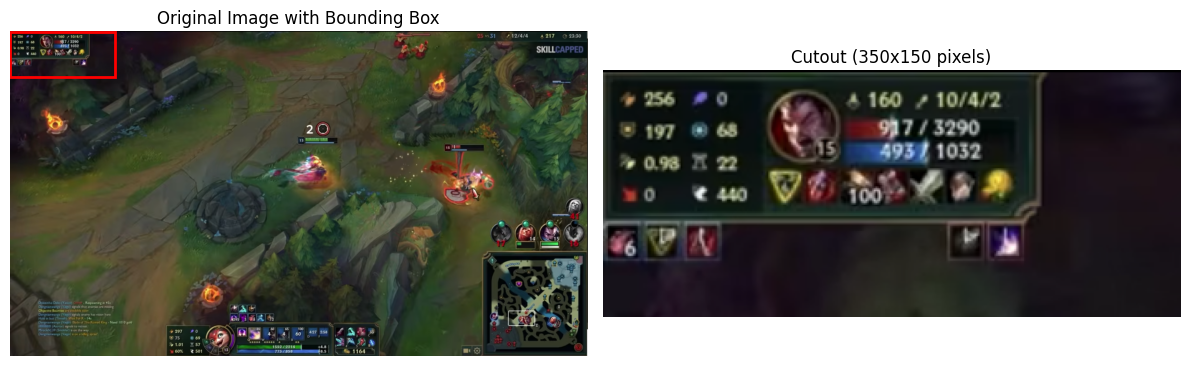


Cutout saved as 'lol_gameplay_top_left_hud.png'


In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


def extract_and_show_cutout(image_path, bbox, show_original=True):
    """
    Extract and display a cutout from an image given a bounding box.
    
    Parameters:
    -----------
    image_path : str
        Path to the input image file
    bbox : tuple or list
        Bounding box coordinates in format (x_min, y_min, x_max, y_max)
        where (x_min, y_min) is the top-left corner and (x_max, y_max) is the bottom-right corner
    show_original : bool, optional
        If True, displays both original image with bbox and the cutout side by side (default: True)
    
    Returns:
    --------
    cutout : PIL.Image
        The extracted cutout image
    
    Example:
    --------
    >>> # Extract a cutout from coordinates (100, 50, 300, 250)
    >>> cutout = extract_and_show_cutout('image.jpg', (100, 50, 300, 250))
    """
    # Load the image
    image = Image.open(image_path)
    
    # Extract bounding box coordinates
    x_min, y_min, x_max, y_max = bbox
    
    # Validate bounding box
    width, height = image.size
    if x_min < 0 or y_min < 0 or x_max > width or y_max > height:
        print(f"Warning: Bounding box {bbox} exceeds image dimensions ({width}x{height})")
        print("Clipping to image boundaries...")
        x_min = max(0, x_min)
        y_min = max(0, y_min)
        x_max = min(width, x_max)
        y_max = min(height, y_max)
    
    if x_min >= x_max or y_min >= y_max:
        raise ValueError(f"Invalid bounding box: {bbox}. Ensure x_min < x_max and y_min < y_max")
    
    # Extract the cutout
    cutout = image.crop((x_min, y_min, x_max, y_max))
    
    # Display the results
    if show_original:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Show original image with bounding box
        axes[0].imshow(image)
        axes[0].add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                        fill=False, edgecolor='red', linewidth=2))
        axes[0].set_title('Original Image with Bounding Box')
        axes[0].axis('off')
        
        # Show cutout
        axes[1].imshow(cutout)
        axes[1].set_title(f'Cutout ({x_max-x_min}x{y_max-y_min} pixels)')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        # Show only the cutout
        plt.figure(figsize=(8, 6))
        plt.imshow(cutout)
        plt.title(f'Cutout ({x_max-x_min}x{y_max-y_min} pixels)')
        plt.axis('off')
        plt.show()
    
    return cutout


def extract_cutout(image_path, bbox):
    """
    Extract a cutout from an image without displaying it.
    
    Parameters:
    -----------
    image_path : str
        Path to the input image file
    bbox : tuple or list
        Bounding box coordinates in format (x_min, y_min, x_max, y_max)
    
    Returns:
    --------
    cutout : PIL.Image
        The extracted cutout image
    """
    image = Image.open(image_path)
    x_min, y_min, x_max, y_max = bbox
    cutout = image.crop((x_min, y_min, x_max, y_max))
    return cutout


# Example usage
if __name__ == "__main__":

    
    # Example 2: Extract and show a cutout
    print("Extracting cutout from the yellow square region...")
    bbox = (0, 0, 350, 150)
    cutout = extract_and_show_cutout('/home/gatv-projects/Desktop/project/playground/lol_gameplay_image.png', bbox)
    
    # Example 3: Save the cutout
    cutout.save('/home/gatv-projects/Desktop/project/playground/lol_gameplay_top_left_hud.png')
    print("\nCutout saved as 'lol_gameplay_top_left_hud.png'")
    
    # # Example 4: Extract without displaying
    # print("\nExtracting another cutout without display...")
    # cutout2 = extract_cutout('/home/gatv-projects/Desktop/project/playground/lol_gameplay_image.png', (0, 0, 200, 200))
    # cutout2.save('/home/gatv-projects/Desktop/project/playground/cutout2.png')
    # print("Second cutout saved as 'cutout2.png'")

In [ ]:
def extract_cutout(image, mask_id, boxes, out_dir="lol_cutouts", save=True, image_id="unknown"):
    """
    Extracts the image cutout for a specific mask ID based on its bounding box.
    Saves the cutout to `out_dir` when save=True, using image_id in the filename.
    """
    import os
    from pathlib import Path

    # 1. Input Validation
    if mask_id < 1 or mask_id > len(boxes):
        raise ValueError(f"Invalid mask_id: {mask_id}. Must be between 1 and {len(boxes)}")

    # 2. Get the box coordinates
    box = boxes[mask_id - 1]

    # Ensure box is on CPU and convert to numpy
    if hasattr(box, "cpu"):
        box = box.cpu().numpy()

    x_min, y_min, x_max, y_max = map(int, box)

    # Clip coordinates to image bounds
    width, height = image.size
    x_min = max(0, min(x_min, width - 1))
    x_max = max(0, min(x_max, width))
    y_min = max(0, min(y_min, height - 1))
    y_max = max(0, min(y_max, height))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError("Bounding box is invalid after clipping to image bounds.")

    # 3. Crop the image
    cutout = image.crop((x_min, y_min, x_max, y_max))

    # 4. Save the cutout
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        
        # --- MODIFICACIÓN AQUÍ ---
        # Si image_id contiene '/', lo limpiamos para que no cree subcarpetas por error
        clean_image_id = str(image_id).replace("/", "_")
        filename = f"cutout_{clean_image_id}_mask_{mask_id}.png"
        # -------------------------
        
        file_path = out_path / filename
        cutout.save(file_path)

    return cutout

# --- Usage Example ---
# 1. Specify which mask you want (e.g., Mask #13)

target_id = 4

# 2. Extract and save (saved to ./lol_cutouts/cutout_mask_13.png)
cutout_image = extract_cutout(image, target_id, boxes, out_dir="lol_cutouts", save=True)
    
# 3. Show
print(f"Saved cutout for Mask #{target_id} to lol_cutouts/cutout_top_left_mask_{target_id}.png")
cutout_image.show()

Saved cutout for Mask #4 to lol_cutouts/cutout_top_left_mask_4.png


Opening in existing browser session.


: 

In [59]:
cutout_path = "/home/gatv-projects/Desktop/project/playground/sam3_testing/lol_cutouts/champions/cutout_Smolder_mask_9.png"
image = Image.open(cutout_path).convert("RGB")
w, h = image.size
aspect_ratio = w / h
if not (0.7 <= aspect_ratio <= 1.4):
    print("No cumple aspect ratio check.")
else:
    print("Cumple aspect ratio check.", aspect_ratio)

Cumple aspect ratio check. 1.0757575757575757


In [1]:
context = {
  "champion": "Smolder",
  "teammates": ["Yasuo", "Morgana", "Warwick", "Velkoz"],
  "transcript": "[0.00s -> 3.08s] You can definitely take chances and look for good fights..."
}

print(", ".join(context['teammates']))

Yasuo, Morgana, Warwick, Velkoz
